In [ ]:
print('test')

In [ ]:
# 개념정리 -매우 중요 
# 인공지능 : 사람처럼 판단하거나 예측하도록 만든 기술.
# 인공지능은 지도학습과 비지도학습으로 나눌 수 있음.

# 지도학습
# 문제와 정답(중요)을 기계에게 주고. 이를 기반으로 학습
# 기계는 학습을 한 후에는 지능을 갖게 되고, 새로운 문제에 대한 예측
# 학생이 공부한 시간(문제)과 성적(정답)을 기계에게 주면
# 기계는 학생이 공부한 시간으로 성적을 학습하게 됩니다.
# 그래서 새로운 공부한 시간의 값이 입력되면 얼마의 성적을 획득할 것인가 예측


# 비지도학습
# 문제만 기계에게 준다. 정답이 없습니다.
# 기계는 스스로 패턴이나 그룹을 찾아 냅니다.
# 점수만 그냥 줍니다. 그리고 점수를 3개의 그룹의 분류해 봐..

# 인공지능은 크게 머신러닝과 딥러닝의 모델이 있습니다.
# 머신러닝은 전통적인 기법이라고 이야기 하고
# 머신러닝은  선형회귀, 결정트리, 부스팅 알고리즘 등이 있다.

# 딥러닝은 사람의 뇌를 모방한 인공신경망으로 구성된 모델입니다.
# 딥러닝은 하드웨어의 자원을 많이 사용합니다.
# 딥러닝은 CNN, LSTM 등이 있다.

## 정말 중요한 팁인데
# 회귀 - 예측하려는 값이 연속된 값, 집값이 얼마냐? 자격증 시험 점수?
# 분류 - 예측하려는 값이 라벨이 있는 것. 자격증 합격/불합격, 개or고양이

## 만약 여러분이 스팸메일 여부를 판다는 모델 개발 > 분류
## 영양제를 먹으면 키가 큰다... 얼마나 클지 > 회귀

## 모델을 개발 할 때 회귀인가 분류인가? 꼭 정답은 아닌데.. 도움이 된다.
## 오늘은 분류는 하지 않습니다. 오늘은 회귀입니다. 


In [ ]:
## 선형 회귀를 공부합니다. 

## 오늘은 인공지능을 이해하는 것이 목표.. <기본기가 탄탄>

In [21]:
import pandas as pd

# 공부한 시간에 따른 점수..
# 지도학습 중 선형회귀
# 문제와 답을 주고 학습을 시키는 것이 지도학습인데 아래 
# 데이터에서 문제가 study_hours 답이  score
# 아래 데이터는 실제 데이터 임. 실제로 아래와 처럼 공부를 했더니..
# 저렇게 점수를 획득
df = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6,7,8,9,10,
                    1,2,3,4,5,6,7,8,9,10],
    "score": [60,55,60,65,70,75,80,82,85,88,
              52,58,62,67,72,76,81,83,86,90]
})

In [22]:
df

,study_hours,score
0,1,60
1,2,55
2,3,60
3,4,65
4,5,70
5,6,75
6,7,80
7,8,82
8,9,85
9,10,88


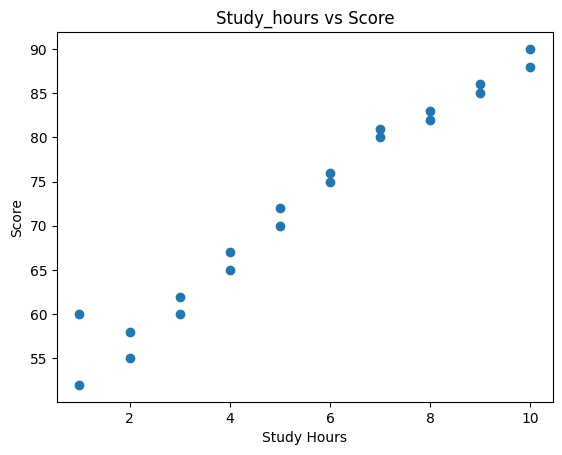

In [23]:
# 데이터를 탐색하기 위해 그래프를 그려본다.
# 중요 : 데이터를 탐색하기 위한 목적은 ? 공부시간에 따른 성적의 변화
# x축을 공부시간, y축을 성적으로 해서 산점도 그래프를 그려 보겠다.
import matplotlib.pyplot as plt

#산점도 그래프
plt.scatter(df['study_hours'], df['score'])
plt.title('Study_hours vs Score')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.show()


In [ ]:
# 선형회귀는 y= ax+b 형태의 직선으로 표현된다.
# x 갑은 입력이고 1개이고, 피처라고 한다. y은 예측값, a는 기울기, b 절편
# 선형회귀모델은 입력데이터로 학습을 하면서
#  y= ax +  b 라는 공식을 만든다.. 예를 y = 2x+b
# 공식이 만들어 지면 새로운 x값 예를 들면 10,
# 새로운 x값을 공식에 대입하여 예측값 y를 만든다.
# 이때 예측값 y는 연속된 값이므로 회귀라고 이해하면 됩니다.

In [24]:
# 모델을 만들어 봅시다.
# 문제지와 정답을 분리해야 한다.

## 변수명은 이렇게 네이밍.. X_train 학습 할 때 문제 데이터 제공
X_train = df[['study_hours']]  # 샘플은 20개, 피처는 1개.. 2차원
## y_train은 정답의 정보로 제공..  지도학습이다. 
y_train = df['score']  #1차원
print(X_train)   # 문제 데이터
print(y_train)   # 정답 데이터

    study_hours
0             1
1             2
2             3
3             4
4             5
5             6
6             7
7             8
8             9
9            10
10            1
11            2
12            3
13            4
14            5
15            6
16            7
17            8
18            9
19           10
0     60
1     55
2     60
3     65
4     70
5     75
6     80
7     82
8     85
9     88
10    52
11    58
12    62
13    67
14    72
15    76
16    81
17    83
18    86
19    90
Name: score, dtype: int64


In [25]:
# 위에서 학습데이터와 정답 데이터를 만들었으니 모델을 만들자.
# 선형회귀 모델을 사용하려면 싸이킷런 라이브러리 필요
# pip install scikit-learn

# 위에서 만든 학습데이터(문제)와 정답을 선형회귀 모델로 개발
from sklearn.linear_model import LinearRegression

model = LinearRegression() # 모델만들기
model.fit(X_train, y_train) # 선형회귀 모델에 문제와 답을 주고 학습

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# 선형회귀는 y=ax+b공식으로 학습하는 모델입니다.
# 기울기와 절편을 확인해 봅니다
print("계수(기울기)",model.coef_)
print("절편 intercept", model.intercept_)

# X_train의 문제의 데이터와  y_train의 정답을 보고 선형회귀에게 학습
# 최종 공식은  y = 4.24545455x + 48.5 공식이 만들어 짐
# 선형회귀가 아닌 다른 모델을 사용한다면 공식이 달라 질 수 있음..

계수(기울기) [3.97272727]
절편 intercept 50.49999999999999


In [27]:
## 시나리오.. 새로운 값으로 성적을 예측해 보자
study_time=[[6],
            [5],
            [12]] #새로운 x값
y_pred = model.predict(study_time)
print(y_pred)

[74.33636364 70.36363636 98.17272727]


d:\Data\260126Tr\AI\Linear\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
## 핵심은
## 지도학습은 문제와 답을 제공해서 학습을 시킨다.
## 선형회귀는 예측하는 결과값이 회귀이고, y = ax +b 공식을 만든다
## 학습데이터의 품질에 따라 선능이 크게 달라 질 수 있다.
## 즉, 데이터의 전처리의 중요성~~**

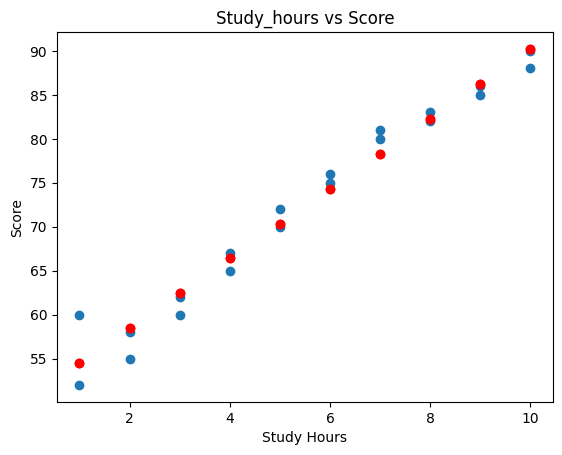

In [28]:
## 실제값과 예측값을 시각화로확인해 보자
import matplotlib.pyplot as plt
#산점도 그래프
plt.scatter(df['study_hours'], df['score'])

#예측값을 산점도로 그려보자
#X_train 데이터로 학습을 시켜서  기울기랑 절편을 구했다.
#이번에는 모델에게 X_train 값을 입력해서 예측해 보도록 한다.
#그러면 실제값과 , 예측한 값의 차이를 알 수 있다. 
y_pred = model.predict(X_train) 
plt.scatter(X_train['study_hours'],y_pred, color='red')

plt.title('Study_hours vs Score')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.show()